In [ ]:
# Install required packages (run once)
# In Colab, run this cell to ensure dependencies are available
!pip install -q torch torchvision albumentations opencv-python matplotlib pytest tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Imports & runtime setup
- Detect GPU, set seeds for reproducibility.

In [ ]:
import os
import random
from pathlib import Path
import shutil
import numpy as np
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

# reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# --- Fast training config (toggle to speed up experiments) ---
# Set FAST_TRAIN=True for quicker runs (smaller images, smaller model, AMP enabled)
FAST_TRAIN = True

# Aggressive mode: much smaller model/input + trimmed training set for very fast iterations
FAST_TRAIN_AGGRESSIVE = False

if FAST_TRAIN_AGGRESSIVE:
    IMG_SIZE = 64
    MODEL_FEATURES = [8, 16]
    BATCH_SIZE = 16
    NUM_WORKERS = min(8, max(1, (os.cpu_count() or 2) - 1))
    USE_AMP = True
    MAX_TRAIN_SAMPLES = 2000  # trim training set per epoch for extremely fast epochs
    TRAIN_EPOCHS = 50         # run more epochs to compensate
elif FAST_TRAIN:
    IMG_SIZE = 96
    MODEL_FEATURES = [16, 32]
    BATCH_SIZE = 8
    NUM_WORKERS = min(4, max(1, (os.cpu_count() or 2) - 1))
    USE_AMP = True
    MAX_TRAIN_SAMPLES = None
    TRAIN_EPOCHS = 30
else:
    IMG_SIZE = 128
    MODEL_FEATURES = [32, 64]
    BATCH_SIZE = 8
    NUM_WORKERS = 2
    USE_AMP = False
    MAX_TRAIN_SAMPLES = None
    TRAIN_EPOCHS = 20

PIN_MEMORY = True if torch.cuda.is_available() else False
print(f'FAST_TRAIN={FAST_TRAIN} FAST_TRAIN_AGGRESSIVE={FAST_TRAIN_AGGRESSIVE} IMG_SIZE={IMG_SIZE} MODEL_FEATURES={MODEL_FEATURES} BATCH_SIZE={BATCH_SIZE} NUM_WORKERS={NUM_WORKERS} USE_AMP={USE_AMP} PIN_MEMORY={PIN_MEMORY} TRAIN_EPOCHS={TRAIN_EPOCHS} MAX_TRAIN_SAMPLES={MAX_TRAIN_SAMPLES}')


Device: cpu
FAST_TRAIN=True FAST_TRAIN_AGGRESSIVE=False IMG_SIZE=96 MODEL_FEATURES=[16, 32] BATCH_SIZE=8 NUM_WORKERS=1 USE_AMP=True PIN_MEMORY=False TRAIN_EPOCHS=30 MAX_TRAIN_SAMPLES=None


## Kaggle (optional) & Google Drive mount
If you have a real dataset on Kaggle you can configure the Kaggle API and download it. To persist checkpoints, mount Google Drive in Colab:

- Kaggle example (run in Colab after setting `KAGGLE_USERNAME` and `KAGGLE_KEY` in env vars):
``!kaggle datasets download -d username/dataset-name -p /content/data``
- Mount Drive: `from google.colab import drive; drive.mount('/content/drive')`

## Synthetic dataset generator (images + segmentation masks)
Generates RGB images and binary masks with irregular blobs that simulate oil spills.

In [ ]:
def make_random_spill_mask(h, w, n_shapes=3):
    mask = np.zeros((h, w), dtype=np.uint8)
    for _ in range(n_shapes):
        t = random.choice(['ellipse', 'poly'])
        if t == 'ellipse':
            center = (random.randint(0, w), random.randint(0, h))
            axes = (random.randint(10, max(10, w // 6)), random.randint(6, max(6, h // 8)))
            angle = random.randint(0, 360)
            cv2.ellipse(mask, center, axes, angle, 0, 360, 255, -1)
        else:
            n_pts = random.randint(3, 8)
            pts = []
            for _ in range(n_pts):
                pts.append([random.randint(0, w), random.randint(0, h)])
            pts = np.array([pts], dtype=np.int32)
            cv2.fillPoly(mask, pts, 255)
    mask = cv2.GaussianBlur(mask, (11, 11), 0)
    _, mask = cv2.threshold(mask, 10, 255, cv2.THRESH_BINARY)
    return mask

def generate_synthetic_dataset(out_dir, n_images=200, img_size=128, seed=42):
    set_seed(seed)
    out_dir = Path(out_dir)
    img_dir = out_dir / 'images'
    mask_dir = out_dir / 'masks'
    if out_dir.exists():
        print(f'Dataset directory {out_dir} exists — skipping generation.')
        return
    img_dir.mkdir(parents=True, exist_ok=True)
    mask_dir.mkdir(parents=True, exist_ok=True)
    h, w = img_size, img_size
    for i in tqdm(range(n_images), desc='Generating dataset'):
        base_color = np.array([random.randint(10, 60), random.randint(50, 120), random.randint(140, 220)])
        img = np.ones((h, w, 3), dtype=np.uint8) * base_color.reshape(1, 1, 3)
        noise = (np.random.randn(h, w, 3) * 10).astype(np.int16)
        img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)
        mask = make_random_spill_mask(h, w, n_shapes=random.randint(1, 4))
        alpha = (mask / 255.0)[..., None] * np.random.uniform(0.2, 0.8)
        img = (img * (1 - alpha) + np.array([10, 10, 10]) * alpha).astype(np.uint8)
        img = cv2.GaussianBlur(img, (3, 3), 0)
        img_path = img_dir / f'img_{i:04d}.png'
        mask_path = mask_dir / f'mask_{i:04d}.png'
        cv2.imwrite(str(img_path), img[..., ::-1])
        cv2.imwrite(str(mask_path), mask)
    print(f'Saved {n_images} synthetic images to {out_dir}')

In [ ]:
# Mount Google Drive (Colab) and configure real-data paths if available
# If running locally, set USE_REAL_DATA = False and the script will generate synthetic data.
USE_REAL_DATA = True  # set to True to use your Drive paths, False to use synthetic data
IMAGE_DIR = '/content/drive/MyDrive/Al_SpilGuard_Project shivanandh/raw_data/images/image'  # <-- your path
MASK_DIR = '/content/drive/MyDrive/Al_SpilGuard_Project shivanandh/raw_data/labels/label'   # <-- your path

if USE_REAL_DATA:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        print('Mounted Google Drive')
    except Exception as e:
        print('Not running in Colab or drive already mounted:', e)
    # basic check that folders exist
    from pathlib import Path
    p_img = Path(IMAGE_DIR)
    p_mask = Path(MASK_DIR)
    if not p_img.exists():
        raise FileNotFoundError(f'Image directory not found: {p_img}')
    if not p_mask.exists():
        raise FileNotFoundError(f'Mask directory not found: {p_mask}')
    print('Using real data:')
    print(' Images:', p_img)
    print(' Masks :', p_mask)
else:
    DATA_DIR = 'data/synth_colab'
    generate_synthetic_dataset(DATA_DIR, n_images=200, img_size=128, seed=42)
    IMAGE_DIR = DATA_DIR + '/images'
    MASK_DIR = DATA_DIR + '/masks'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mounted Google Drive
Using real data:
 Images: /content/drive/MyDrive/Al_SpilGuard_Project shivanandh/raw_data/images/image
 Masks : /content/drive/MyDrive/Al_SpilGuard_Project shivanandh/raw_data/labels/label


## PyTorch Dataset & DataLoader
Implement a `Dataset` that reads generated images and masks and returns tensors.

In [ ]:
class SpillDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transforms=None):
        self.images = sorted([str(p) for p in Path(images_dir).glob('*.png')])
        self.masks = sorted([str(p) for p in Path(masks_dir).glob('*.png')])
        assert len(self.images) == len(self.masks), 'Images and masks counts do not match'
        self.transforms = transforms

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = cv2.imread(self.images[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.masks[idx], cv2.IMREAD_GRAYSCALE)
        if self.transforms:
            augmented = self.transforms(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']
        # `augmented['image']` may be either a numpy array or a torch.Tensor depending on transforms
        # Avoid double-scaling: only divide by 255 if we still have a numpy uint8 image.
        if isinstance(img, np.ndarray):
            img = torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0
        elif isinstance(img, torch.Tensor):
            img = img.float()
        else:
            raise TypeError('Unsupported image type: {}'.format(type(img)))
        if isinstance(mask, np.ndarray):
            mask = torch.from_numpy(mask).unsqueeze(0).float() / 255.0
        elif isinstance(mask, torch.Tensor):
            # ensure channel-first and float dtype
            if mask.dim() == 3:
                mask = mask.float()
            else:
                mask = mask.unsqueeze(0).float()
            # if mask values are in 0..255 (common), scale to 0..1
            try:
                if mask.max() > 1.5:
                    mask = mask / 255.0
            except Exception:
                pass
        else:
            raise TypeError('Unsupported mask type: {}'.format(type(mask)))
        return img, mask


def get_transforms(img_size=128, mode='train'):
    if mode == 'train':
        return A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.2),
            A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=25, p=0.5),
            A.RandomBrightnessContrast(p=0.4),
            A.GaussianBlur(p=0.2),
            A.Normalize(),
            ToTensorV2()
        ])
    else:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(),
            ToTensorV2()
        ])


# New: dataset that accepts explicit (img_path, mask_path) pairs (no copying required)
class PairsDataset(Dataset):
    def __init__(self, pairs, transforms=None):
        self.pairs = list(pairs)
        self.transforms = transforms

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_p, mask_p = self.pairs[idx]
        img = cv2.imread(str(img_p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(mask_p), cv2.IMREAD_GRAYSCALE)
        if self.transforms:
            augmented = self.transforms(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']
        # convert only when we still have numpy arrays (avoid double scaling when transforms already produced tensors)
        if isinstance(img, np.ndarray):
            img = torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0
        elif isinstance(img, torch.Tensor):
            img = img.float()
        else:
            raise TypeError('Unsupported image type: {}'.format(type(img)))
        if isinstance(mask, np.ndarray):
            mask = torch.from_numpy(mask).unsqueeze(0).float() / 255.0
        elif isinstance(mask, torch.Tensor):
            if mask.dim() == 3:
                mask = mask.float()
            else:
                mask = mask.unsqueeze(0).float()
            try:
                if mask.max() > 1.5:
                    mask = mask / 255.0
            except Exception:
                pass
        else:
            raise TypeError('Unsupported mask type: {}'.format(type(mask)))
        return img, mask


# Helper to denormalize tensors that were normalized with albumentations' default Normalize
def denorm_tensor(img_t):
    # img_t: tensor CxHxW in range normalized by A.Normalize() default (mean,std)=((0.485,0.456,0.406),(0.229,0.224,0.225))
    arr = img_t.cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    arr = (arr * std) + mean
    arr = np.clip(arr, 0.0, 1.0)
    return arr

Found 3357 images and 3354 masks in provided folders


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipython-input-1542676017.py:76: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 30.0), p=0.3),


Matched pairs: 3357
Augmenting dataset from 3357 -> 6400 pairs (will create 3043 augmented samples)


Augmenting:   3%|▎         | 103/3043 [00:43<02:39, 18.38img/s]

Created 100 augmented images, total pairs now 3457


...

Created 2900 augmented images, total pairs now 6257


Augmenting:  99%|█████████▊| 3003/3043 [03:38<00:02, 17.97img/s]

Created 3000 augmented images, total pairs now 6357


Augmenting: 100%|██████████| 3043/3043 [03:41<00:00, 13.77img/s]


Augmentation complete. Created 3043 images. Total pairs: 6400


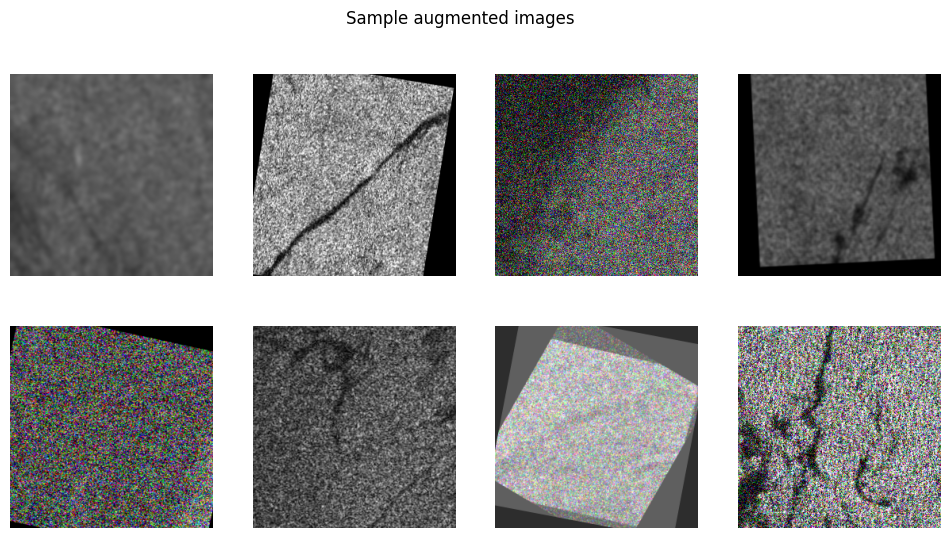

Batch shapes: torch.Size([8, 3, 96, 96]) torch.Size([8, 1, 96, 96])


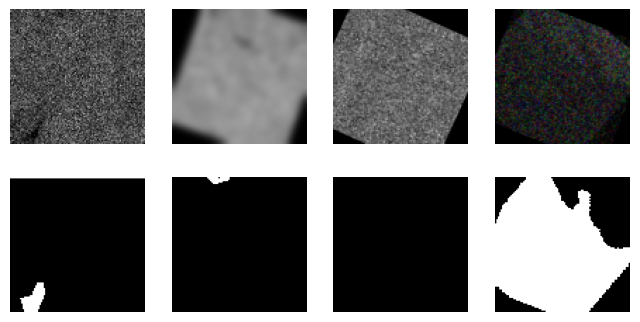

In [ ]:
# Create train/val/test splits and DataLoaders quickly (no file copying)
from pathlib import Path
import re
import math
from tqdm import tqdm

# ensure config variables exist (safe fallbacks if import/config cell wasn't re-run)
try:
    IMG_SIZE
except NameError:
    IMG_SIZE = 128
    MODEL_FEATURES = [32, 64]
    BATCH_SIZE = 8
    NUM_WORKERS = 2
    PIN_MEMORY = False
    USE_AMP = False
    MAX_TRAIN_SAMPLES = None

# build canonical key function to handle names like '1591 (1).png' -> '1591'
def canonical_key(path):
    name = Path(path).stem
    # remove trailing parenthetical duplicates e.g. ' (1)'
    name = re.sub(r"\s*\(\d+\)$", "", name)
    return name.lower().strip()

# gather image paths and masks, match by canonical filename
img_paths = sorted(list(Path(IMAGE_DIR).glob('*.png')))
mask_paths = sorted(list(Path(MASK_DIR).glob('*.png')))
print(f'Found {len(img_paths)} images and {len(mask_paths)} masks in provided folders')

masks_map = {}
for p in mask_paths:
    masks_map[canonical_key(p)] = p

pairs = []
unmatched_imgs = []
for p in img_paths:
    k = canonical_key(p)
    if k in masks_map:
        pairs.append((p, masks_map[k]))
    else:
        unmatched_imgs.append(p)

unmatched_masks = [p for p in mask_paths if canonical_key(p) not in {canonical_key(i) for i, _ in pairs}]
print(f'Matched pairs: {len(pairs)}')
if len(unmatched_imgs) > 0:
    print('Unmatched images (sample up to 10):', [p.name for p in unmatched_imgs[:10]])
if len(unmatched_masks) > 0:
    print('Unmatched masks (sample up to 10):', [p.name for p in unmatched_masks[:10]])

if len(pairs) == 0:
    raise RuntimeError('No matching image/mask pairs found. Ensure filenames of images and masks match exactly or adjust canonical_key.')

# --- Augmentation to reach target size ---
TARGET_COUNT = 6400
if len(pairs) < TARGET_COUNT:
    to_create = TARGET_COUNT - len(pairs)
    print(f'Augmenting dataset from {len(pairs)} -> {TARGET_COUNT} pairs (will create {to_create} augmented samples)')
    # where to save augmented pairs
    if USE_REAL_DATA:
        AUG_DIR = Path(IMAGE_DIR).parents[2] / 'augmented'  # try to place under the same raw_data folder
    else:
        AUG_DIR = Path('data') / 'augmented'
    img_out = AUG_DIR / 'images'
    mask_out = AUG_DIR / 'masks'
    img_out.mkdir(parents=True, exist_ok=True)
    mask_out.mkdir(parents=True, exist_ok=True)

    # augmentation pipeline for saving (no Normalize/ToTensor)
    aug_save = A.Compose([
        A.RandomRotate90(p=0.5),
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15, rotate_limit=20, p=0.7),
        A.RandomBrightnessContrast(p=0.5),
        A.GaussianBlur(p=0.2),
        A.GaussNoise(var_limit=(5.0, 30.0), p=0.3),
        A.ElasticTransform(p=0.2)
    ])

    rng = random.Random(42)
    current = len(pairs)
    created = 0
    # use tqdm to show progress and ETA
    for _ in tqdm(range(to_create), desc='Augmenting', unit='img'):
        src_img, src_mask = pairs[rng.randrange(len(pairs))]
        img = cv2.imread(str(src_img))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(src_mask), cv2.IMREAD_GRAYSCALE)
        augmented = aug_save(image=img, mask=mask)
        aug_img = augmented['image']
        aug_mask = augmented['mask']
        # ensure mask is binary
        _, aug_mask = cv2.threshold(aug_mask, 127, 255, cv2.THRESH_BINARY)
        # save with unique index
        out_img_name = f'aug_img_{current:06d}.png'
        out_mask_name = f'aug_mask_{current:06d}.png'
        cv2.imwrite(str(img_out / out_img_name), cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))
        cv2.imwrite(str(mask_out / out_mask_name), aug_mask)
        # add to pairs list
        pairs.append((img_out / out_img_name, mask_out / out_mask_name))
        current += 1
        created += 1
        # occasional logging for disk flush visibility
        if created % 100 == 0:
            print(f'Created {created} augmented images, total pairs now {current}')
    print(f'Augmentation complete. Created {created} images. Total pairs: {len(pairs)}')
    # Display a small sample of augmented images so you can visually verify augmentation
    try:
        n_show = min(8, created)
        if n_show > 0:
            aug_imgs = sorted(list(img_out.glob('*.png')))[-n_show:]
            plt.figure(figsize=(12, 3 * math.ceil(n_show/4)))
            for i, pth in enumerate(aug_imgs):
                im = cv2.imread(str(pth))
                im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
                ax = plt.subplot(math.ceil(n_show/4), 4, i+1)
                ax.imshow(im)
                ax.axis('off')
            plt.suptitle('Sample augmented images')
            plt.show()
    except Exception as e:
        print('Could not display augmented samples:', e)
else:
    print('No augmentation needed (already >= TARGET_COUNT)')

# split indices
indices = list(range(len(pairs)))
random.shuffle(indices)
n = len(indices)
train_idx = indices[: int(0.7 * n)]
val_idx = indices[int(0.7 * n): int(0.85 * n)]
test_idx = indices[int(0.85 * n):]

train_pairs = [pairs[i] for i in train_idx]
val_pairs = [pairs[i] for i in val_idx]
test_pairs = [pairs[i] for i in test_idx]

# If configured for FAST trimming, reduce training set size to speed up epochs
if 'MAX_TRAIN_SAMPLES' in globals() and MAX_TRAIN_SAMPLES is not None:
    original_train = len(train_pairs)
    if original_train > MAX_TRAIN_SAMPLES:
        train_pairs = train_pairs[:MAX_TRAIN_SAMPLES]
        print(f'Trimmed training set from {original_train} -> {len(train_pairs)} samples for fast training')

# create datasets from pairs (no copying)
train_ds = PairsDataset(train_pairs, transforms=get_transforms(IMG_SIZE, 'train'))
val_ds = PairsDataset(val_pairs, transforms=get_transforms(IMG_SIZE, 'val'))
test_ds = PairsDataset(test_pairs, transforms=get_transforms(IMG_SIZE, 'val'))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=(NUM_WORKERS>0), prefetch_factor=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=(NUM_WORKERS>0), prefetch_factor=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=(NUM_WORKERS>0), prefetch_factor=2)

# Display a sample batch (first batch) with denormalization
imgs, masks = next(iter(train_loader))
print('Batch shapes:', imgs.shape, masks.shape)
plt.figure(figsize=(8,4))
for i in range(min(4, imgs.shape[0])):
    ax = plt.subplot(2,4,i+1)
    im = denorm_tensor(imgs[i])
    ax.imshow(im)
    ax.axis('off')
    ax = plt.subplot(2,4,i+5)
    ax.imshow(masks[i][0].numpy(), cmap='gray')
    ax.axis('off')
plt.show()


## Model: Lightweight U-Net implementation (PyTorch)
A compact U-Net that trains quickly on synthetic data.

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[32,64]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        for f in features:
            self.downs.append(ConvBlock(in_channels, f))
            in_channels = f
        self.bottleneck = ConvBlock(features[-1], features[-1]*2)
        rev_features = features[::-1]
        up_in = features[-1]*2
        for f in rev_features:
            self.ups.append(nn.ConvTranspose2d(up_in, f, kernel_size=2, stride=2))
            self.ups.append(ConvBlock(up_in, f))
            up_in = f
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)
        self.pool = nn.MaxPool2d(2)
    def forward(self, x):
        skip_connections = []
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        for i in range(0, len(self.ups), 2):
            upconv = self.ups[i]
            conv = self.ups[i+1]
            x = upconv(x)
            skip = skip_connections[-(i//2+1)]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:])
            x = torch.cat([skip, x], dim=1)
            x = conv(x)
        return self.final_conv(x)

# instantiate model using configured features
model = UNet(in_channels=3, out_channels=1, features=MODEL_FEATURES).to(device)
print('Model param count:', sum(p.numel() for p in model.parameters() if p.requires_grad))


Model param count: 117681


## Losses & metrics (Dice, IoU with formulas)
Formulas:
$$\mathrm{IoU}=\frac{TP}{TP+FP+FN}$$
$$\mathrm{Dice}=\frac{2TP}{2TP+FP+FN}$$

In [ ]:
bce_loss = nn.BCEWithLogitsLoss()
def dice_coeff(pred, target, eps=1e-6):
    # ensure target in 0..1
    target = target.float()
    try:
        if target.max() > 1.5:
            target = target / 255.0
    except Exception:
        pass
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    intersect = (pred * target).sum(dim=[1,2,3])
    union = pred.sum(dim=[1,2,3]) + target.sum(dim=[1,2,3])
    dice = (2 * intersect + eps) / (union + eps)
    return dice.mean().item()

def iou_score(pred, target, eps=1e-6):
    # ensure target in 0..1
    target = target.float()
    try:
        if target.max() > 1.5:
            target = target / 255.0
    except Exception:
        pass
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    inter = (pred * target).sum(dim=[1,2,3])
    union = (pred + target - pred * target).sum(dim=[1,2,3])
    iou = (inter + eps) / (union + eps)
    return iou.mean().item()

def dice_loss(pred, target):
    # ensure target in 0..1
    target = target.float()
    try:
        if target.max() > 1.5:
            target = target / 255.0
    except Exception:
        pass
    pred = torch.sigmoid(pred)
    intersect = (pred * target).sum(dim=[1,2,3])
    union = pred.sum(dim=[1,2,3]) + target.sum(dim=[1,2,3])
    loss = 1 - ((2 * intersect + 1e-6) / (union + 1e-6))
    return loss.mean()

## Training loop with logging, checkpointing & early stopping
A compact training loop that saves the best model by validation IoU.

In [ ]:
def train_model(model, train_loader, val_loader, device, epochs=5, lr=1e-3, save_dir='checkpoints'):
    os.makedirs(save_dir, exist_ok=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_iou = 0.0
    patience = 3
    wait = 0
    scaler = None
    if USE_AMP and device.type == 'cuda':
        scaler = torch.cuda.amp.GradScaler()
    for epoch in range(1, epochs+1):
        model.train()
        t_loss = 0.0
        loop = tqdm(train_loader, desc=f'Train epoch {epoch}')
        for imgs, masks in loop:
            imgs = imgs.to(device, non_blocking=PIN_MEMORY)
            masks = masks.to(device, non_blocking=PIN_MEMORY)
            if scaler is not None:
                with torch.cuda.amp.autocast():
                    preds = model(imgs)
                    loss = bce_loss(preds, masks) + dice_loss(preds, masks)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            else:
                preds = model(imgs)
                loss = bce_loss(preds, masks) + dice_loss(preds, masks)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            t_loss += loss.item() * imgs.size(0)
        t_loss /= len(train_loader.dataset)
        model.eval()
        val_iou = 0.0
        val_dice = 0.0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs = imgs.to(device, non_blocking=PIN_MEMORY)
                masks = masks.to(device, non_blocking=PIN_MEMORY)
                preds = model(imgs)
                val_iou += iou_score(preds, masks) * imgs.size(0)
                val_dice += dice_coeff(preds, masks) * imgs.size(0)
        val_iou /= len(val_loader.dataset)
        val_dice /= len(val_loader.dataset)
        print(f'Epoch {epoch}: TrainLoss={t_loss:.4f} ValIoU={val_iou:.4f} ValDice={val_dice:.4f}')
        if val_iou > best_iou:
            best_iou = val_iou
            wait = 0
            torch.save({'model_state': model.state_dict()}, os.path.join(save_dir, 'best.pth'))
        else:
            wait += 1
            if wait >= patience:
                print('Early stopping')
                break
    print('Training complete. Best val IoU:', best_iou)


In [ ]:
# Run quick training (few epochs for demo)
model = UNet(in_channels=3, out_channels=1, features=MODEL_FEATURES).to(device)
train_model(model, train_loader, val_loader, device, epochs=TRAIN_EPOCHS, lr=1e-3, save_dir='checkpoints')


Train epoch 1: 100%|██████████| 560/560 [05:15<00:00,  1.77it/s]


Epoch 1: TrainLoss=1.0429 ValIoU=0.4812 ValDice=0.6060


Train epoch 2: 100%|██████████| 560/560 [04:34<00:00,  2.04it/s]


Epoch 2: TrainLoss=0.9376 ValIoU=0.4521 ValDice=0.5811


Train epoch 3: 100%|██████████| 560/560 [04:32<00:00,  2.05it/s]


...

Epoch 8: TrainLoss=0.8266 ValIoU=0.5423 ValDice=0.6632


Train epoch 9: 100%|██████████| 560/560 [04:23<00:00,  2.12it/s]


Epoch 9: TrainLoss=0.8159 ValIoU=0.5526 ValDice=0.6747


Train epoch 10: 100%|██████████| 560/560 [04:22<00:00,  2.14it/s]


Epoch 10: TrainLoss=0.8068 ValIoU=0.5558 ValDice=0.6754
Early stopping
Training complete. Best val IoU: 0.5580804908027251


## Evaluation on synthetic test set & visualizations
Run evaluation and plot image / GT / predicted masks.

Test IoU=0.5515 Test Dice=0.6766


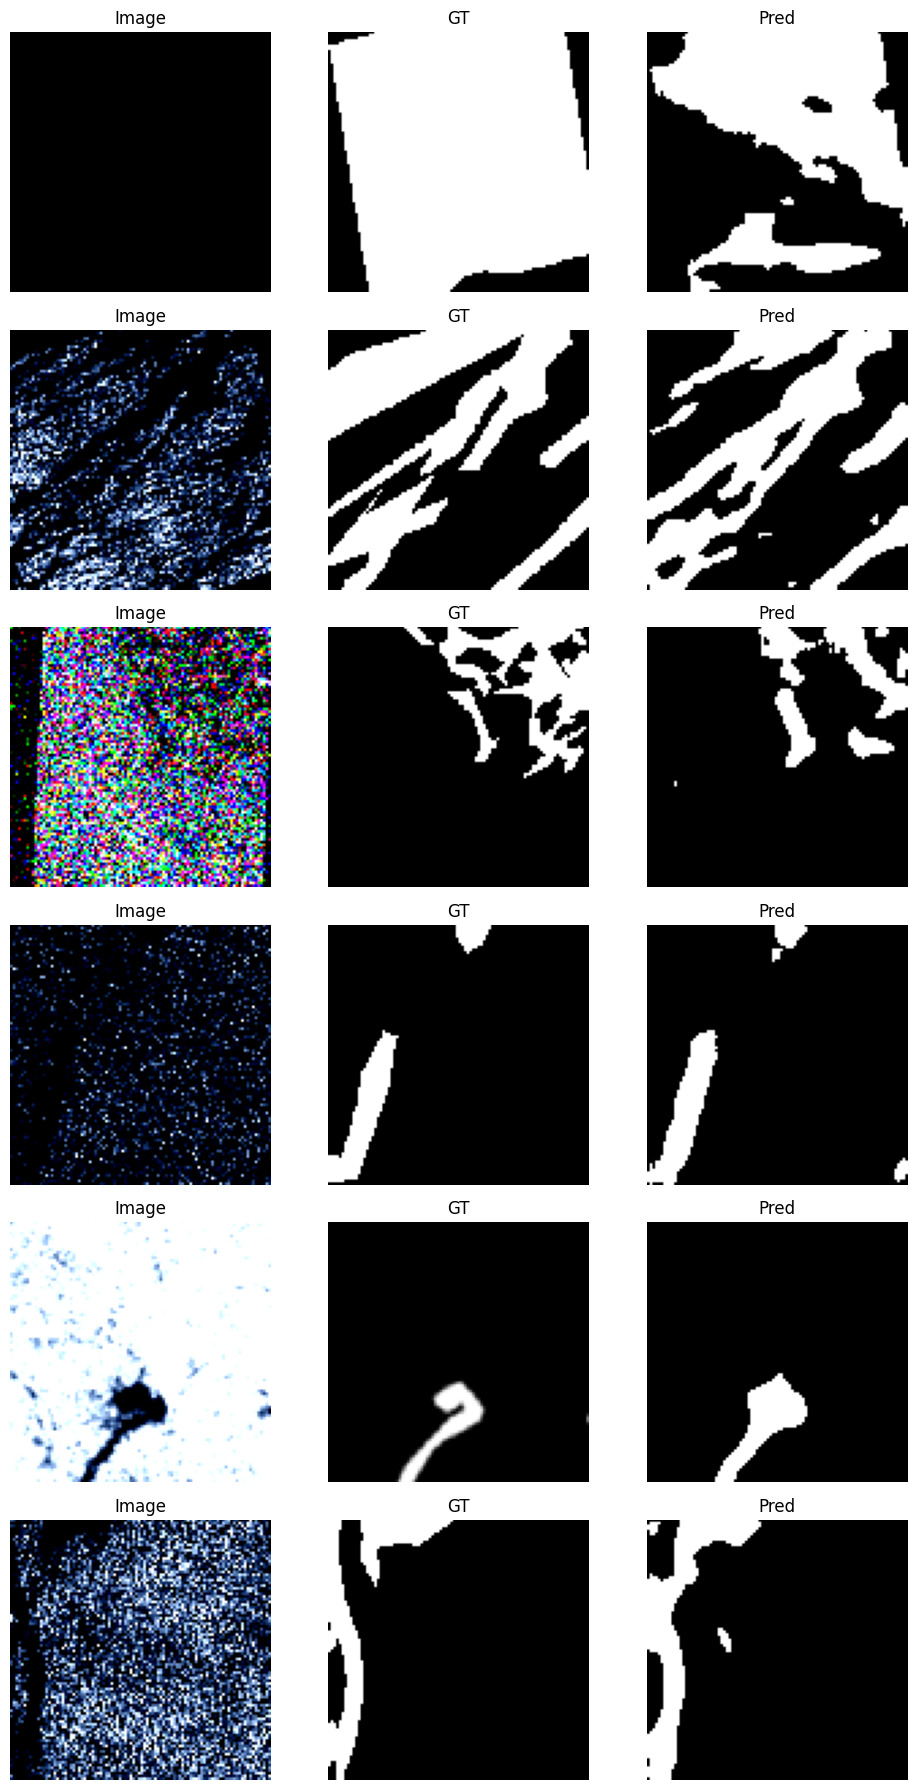

In [ ]:
def evaluate_and_visualize(model, data_loader, device, n_samples=6):
    model.eval()
    iou_total = 0.0
    dice_total = 0.0
    with torch.no_grad():
        for imgs, masks in data_loader:
            imgs = imgs.to(device)
            masks = masks.to(device)
            preds = model(imgs)
            iou_total += iou_score(preds, masks) * imgs.size(0)
            dice_total += dice_coeff(preds, masks) * imgs.size(0)
    iou_total /= len(data_loader.dataset)
    dice_total /= len(data_loader.dataset)
    print(f'Test IoU={iou_total:.4f} Test Dice={dice_total:.4f}')
    samples = 0
    plt.figure(figsize=(10, n_samples * 3))
    for imgs, masks in data_loader:
        imgs = imgs.to(device)
        masks = masks.to(device)
        preds = torch.sigmoid(model(imgs))
        preds = (preds > 0.5).float()
        for i in range(imgs.size(0)):
            if samples >= n_samples:
                break
            img_np = imgs[i].cpu().numpy().transpose(1,2,0)
            mask_np = masks[i].cpu().numpy().squeeze()
            pred_np = preds[i].cpu().numpy().squeeze()
            ax = plt.subplot(n_samples, 3, samples * 3 + 1)
            ax.imshow(img_np)
            ax.set_title('Image')
            ax.axis('off')
            ax = plt.subplot(n_samples, 3, samples * 3 + 2)
            ax.imshow(mask_np, cmap='gray')
            ax.set_title('GT')
            ax.axis('off')
            ax = plt.subplot(n_samples, 3, samples * 3 + 3)
            ax.imshow(pred_np, cmap='gray')
            ax.set_title('Pred')
            ax.axis('off')
            samples += 1
        if samples >= n_samples:
            break
    plt.tight_layout()
    plt.show()

# Load best checkpoint if exists and run evaluation
ckpt_path = Path('checkpoints') / 'best.pth'
if ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model_state'])
evaluate_and_visualize(model, test_loader, device, n_samples=6)

## Inference function for single image
Helper to predict mask on a single PIL/ndarray image and return overlay.

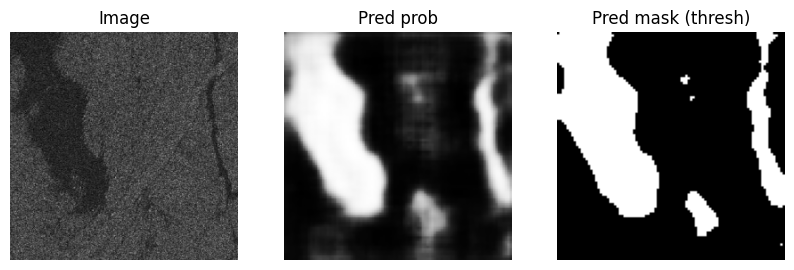

In [ ]:
def predict_single(model, image_np, device, img_size=IMG_SIZE, threshold=0.5):
    model.eval()
    # Accept either uint8 0..255 images or float 0..1 images. Normalize and tensorize via albumentations.
    if isinstance(image_np, torch.Tensor):
        # convert tensor HxWxC or CxHxW to numpy HxWxC uint8 if needed
        img_arr = image_np.detach().cpu().numpy()
        if img_arr.ndim == 3 and img_arr.shape[0] == 3:
            # CxHxW -> HxWxC
            img_arr = img_arr.transpose(1, 2, 0)
        # assume floats in 0..1 -> convert to 0..255
        if img_arr.dtype != np.uint8:
            image_to_use = (np.clip(img_arr, 0.0, 1.0) * 255.0).astype(np.uint8)
        else:
            image_to_use = img_arr
    else:
        img_arr = np.array(image_np)
        if img_arr.dtype != np.uint8:
            image_to_use = (np.clip(img_arr, 0.0, 1.0) * 255.0).astype(np.uint8)
        else:
            image_to_use = img_arr
    aug = A.Compose([A.Resize(img_size, img_size), A.Normalize(), ToTensorV2()])
    augmented = aug(image=image_to_use)
    t = augmented['image'].unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(t)
        pred_prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
    pred_bin = (pred_prob > threshold).astype(np.uint8)
    # return binary mask first (for backward compatibility) and the probability map
    return pred_bin, pred_prob

# Example usage: take first test image
# Use the resized original for display so overlay aligns with predicted mask size
test_img_path = sorted(list((Path('splits') / 'test' / 'images').glob('*.png')))[0]
im = cv2.imread(str(test_img_path))
im_rgb = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
pred_mask_bin, pred_mask_prob = predict_single(model, im_rgb, device, img_size=IMG_SIZE)
plt.figure(figsize=(10,5))
plt.subplot(1,3,1); plt.imshow(im_rgb); plt.axis('off'); plt.title('Image')
plt.subplot(1,3,2); plt.imshow(pred_mask_prob, cmap='gray'); plt.axis('off'); plt.title('Pred prob')
plt.subplot(1,3,3); plt.imshow(pred_mask_bin, cmap='gray'); plt.axis('off'); plt.title('Pred mask (thresh)')
plt.show()


## Saving / loading model weights
Save the best checkpoint during training with `torch.save` and load with `torch.load(..., map_location=device)` to resume or perform inference.

In [ ]:
# Save current model (example)
torch.save({'model_state': model.state_dict()}, 'model_latest.pth')
# Load example
# ckpt = torch.load('model_latest.pth', map_location=device)
# model.load_state_dict(ckpt['model_state'])
print('Saved model_latest.pth')

Saved model_latest.pth


## Unit tests (pytest) for data loader, model forward, metrics
Create small tests and run `pytest -q` in Colab. The repository already contains `tests/` but you can run them from the notebook.

In [ ]:
# Example: run pytest (will pick up tests/ if present)
!pytest -q || true


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! KeyboardInterrupt !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
/usr/lib/python3.12/pathlib.py:52: KeyboardInterrupt
(to show a full traceback on KeyboardInterrupt use --full-trace)
no tests ran in 13.25s
Traceback (most recent call last):
  File "/usr/local/bin/pytest", line 10, in <module>
    sys.exit(console_main())
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/_pytest/config/__init__.py", line 201, in console_main
    code = main()
           ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/_pytest/config/__init__.py", line 175, in main
    ret: ExitCode | int = config.hook.pytest_cmdline_main(config=config)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pluggy/_hooks.py", line 512, in __call__
    return self._hookexec(self.name, self._hookimpls.copy(), kwargs, firstresult)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

## Colab runtime tips
- Enable GPU: Runtime -> Change runtime type -> GPU.
- Monitor RAM/GPU with: `!nvidia-smi` and `!free -h`.
- If you hit OOM, reduce `batch_size` or `img_size`.
- To persist checkpoints, mount Google Drive and save under `/content/drive/MyDrive/...`.